In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df=pd.read_csv('Salary_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [5]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [20]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

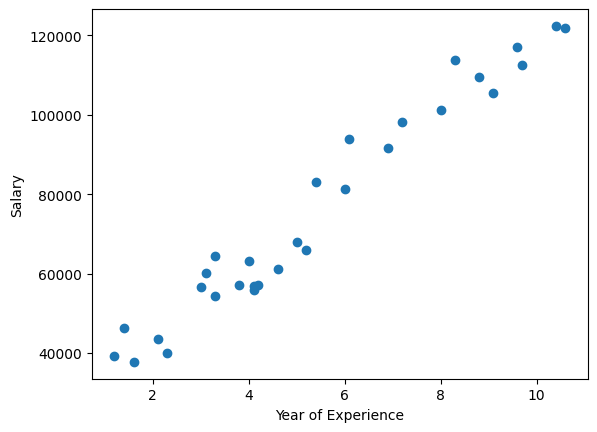

In [6]:
##Plotting scatter graph to see where is my data points
plt.scatter(x='YearsExperience',y='Salary',data=df)
plt.xlabel("Year of Experience")
plt.ylabel("Salary")
plt.show()


In [7]:
##Finding correlation
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


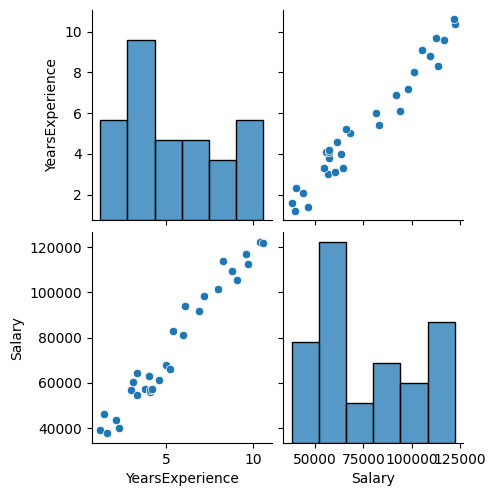

In [8]:
import seaborn as sns
sns.pairplot(df)

In [9]:
##Geting independent and dependent feature
X=df[['YearsExperience']]
y=df['Salary']

In [10]:
##Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
X_train

,YearsExperience
12,4.1
0,1.2
4,2.3
16,5.2
5,3.0
13,4.2
11,4.1
22,8.0
1,1.4
2,1.6


In [12]:
##Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
## Applying linear regression model
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
## Finding coefficient and intercept
print(regression.coef_)
print(regression.intercept_)

[25063.1519945]
70417.40909090909


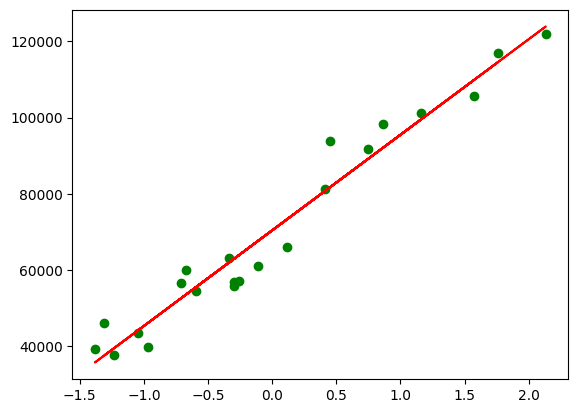

In [31]:
## Ploting training data plot best fit line
plt.scatter(X_train,y_train,color='g')
plt.plot(X_train,regression.predict(X_train),color='r')

In [16]:
## Prediction for test data
y_pred=regression.predict(X_test)

In [21]:
## Performance metrix
import math
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

38802588.99247059
5056.9954666635895
6229.172416338352


In [22]:
##Checking performance percentage
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.9347210011126783


In [23]:
##Performance by adjusted r2
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.9238411679647913

In [24]:
## OLS linear regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
predict=model.predict(X_test)
print(predict)

[ 45023.47271018    979.6971356   31904.0501986    4728.10356748
 -14951.03019988 -10265.52216003  51583.18396597  36589.55823845]


In [25]:
## Getting summary
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.112
Model:                            OLS   Adj. R-squared (uncentered):              0.070
Method:                 Least Squares   F-statistic:                              2.645
Date:                Sat, 14 Feb 2026   Prob (F-statistic):                       0.119
Time:                        18:56:12   Log-Likelihood:                         -276.85
No. Observations:                  22   AIC:                                      555.7
Df Residuals:                      21   BIC:                                      556.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [29]:
## Prediction for new data
regression.predict(scaler.transform([[4.5]]))

c:\Users\amitk\OneDrive\Desktop\complete data analyst bootcamp\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([66711.59818667])